In [75]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#PART 1

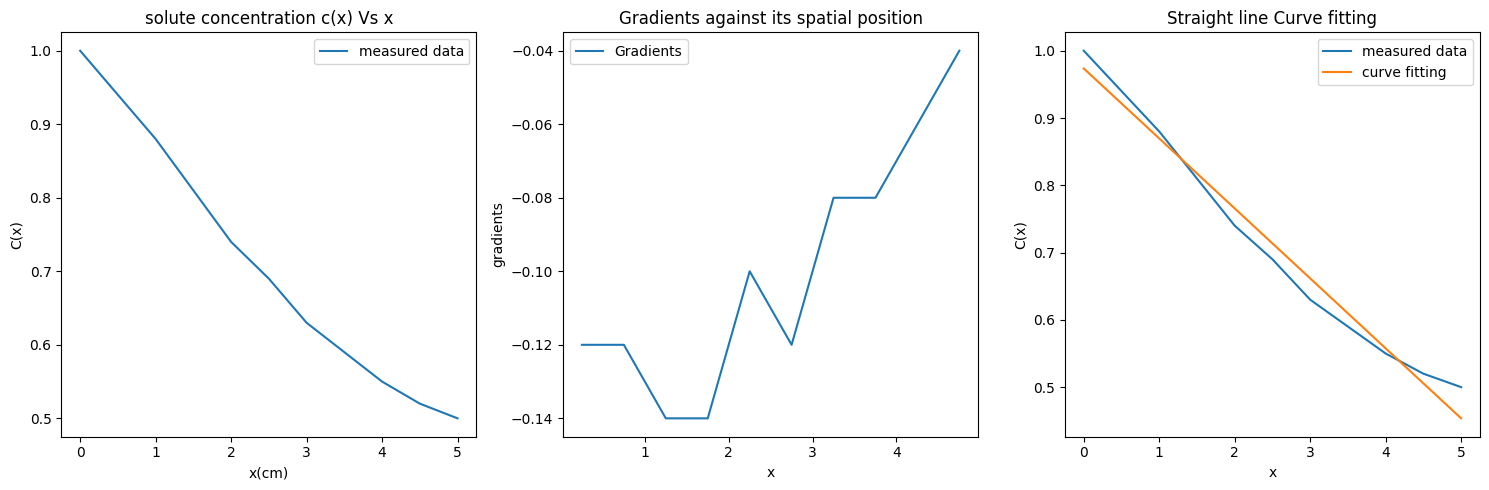

Gradient: [np.float64(-0.1200000000000001), np.float64(-0.11999999999999988), np.float64(-0.1399999999999999), np.float64(-0.14000000000000012), np.float64(-0.10000000000000009), np.float64(-0.11999999999999988), np.float64(-0.08000000000000007), np.float64(-0.07999999999999985), np.float64(-0.06000000000000005), np.float64(-0.040000000000000036)]
Spatial Gradient location: [np.float64(0.25), np.float64(0.75), np.float64(1.25), np.float64(1.75), np.float64(2.25), np.float64(2.75), np.float64(3.25), np.float64(3.75), np.float64(4.25), np.float64(4.75)]
Slope: -0.10399999985648277
Intercept: 0.9736363632775705
error in slope: 0.00501091551641389
error in intercept: 0.014822487967230848


In [76]:
#Mesurements
x = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])  #(cm)
cx = np.array([1.00, 0.94, 0.88, 0.81, 0.74, 0.69, 0.63, 0.59, 0.55, 0.52, 0.50]) #(arb. units)

#calculating gradient
gradient = []
gradient_spatial_loc = []

for i in range(1, len(x)):
  gradients = (cx[i] - cx[i-1])/(x[i] - x[i-1])
  gradient.append(gradients)
  gradient_spatial_loc.append((x[i] + x[i-1])/2)


#curve fitting
def straight_line(x, m, c):
  return m*x + c

popt, pcov = curve_fit(straight_line, x, cx)
#intercepts
m, c = popt
#error in parameters
sigma_m, sigma_c = np.sqrt(np.diag(pcov))


#fitted line
cx_fit = straight_line(x, m, c)

#Graphs plot
fig, ax = plt.subplots(1, 3, figsize=(15,5))

#graph for solute concentration c(x) vs x
ax[0].plot(x, cx, label="measured data")
ax[0].set_title("solute concentration c(x) Vs x")
ax[0].set_xlabel("x(cm)")
ax[0].set_ylabel("C(x)")
ax[0].legend()

#graph for gradients
ax[1].plot(gradient_spatial_loc, gradient, label="Gradients")
ax[1].set_title("Gradients against its spatial position")
ax[1].set_xlabel("x")
ax[1].set_ylabel("gradients")
ax[1].legend()

#curve fitting(straight_line)
ax[2].plot(x, cx, label="measured data")
ax[2].plot(x, cx_fit, label="curve fitting")
ax[2].set_title("Straight line Curve fitting")
ax[2].set_xlabel("x")
ax[2].set_ylabel("C(x)")
ax[2].legend()

#tight layout
plt.tight_layout()
plt.show()

#print the results
print(f"Gradient: {gradient}")
print(f"Spatial Gradient location: {gradient_spatial_loc}")
print(f"Slope: {m}")
print(f"Intercept: {c}")

#error in slope and intercept
print(f'error in slope: {sigma_m}')
print(f'error in intercept: {sigma_c}')

#PART 2

Diffusive transport is governed by Fick’s law:

$$J(x) = -D \dfrac{dc}{dx}$$

where $J(x)$ is the diffusive flux along the $x$ direction and $D$ = 0.10$cm^2/s$

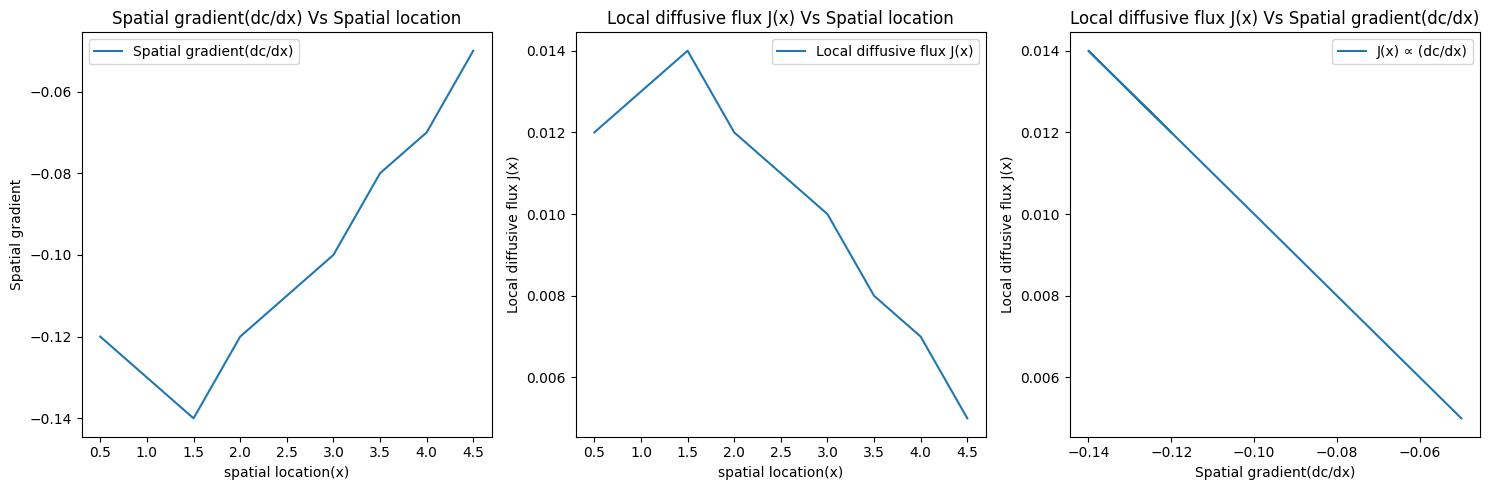

Spatial Gradient(dc/dx): [-0.12 -0.13 -0.14 -0.12 -0.11 -0.1  -0.08 -0.07 -0.05]
Local diffusive flux J(x): [0.012 0.013 0.014 0.012 0.011 0.01  0.008 0.007 0.005]


In [77]:
#stepsize
h = 0.5

#value of Diffusion coeffiecient
D = 0.10 #cm^2/s

#spatial gradient
cx_diff = []

#differentian using central difference method
for i in range(1, len(x)-1):
  cx_differentiation = (cx[i+1] - cx[i-1])/(2*h)
  cx_diff.append(cx_differentiation)

cx_diff = np.array(cx_diff)

#Local diffusive flux
def J(D, cx_diff):
  return -D*cx_diff

local_diffusive_flux = J(D, cx_diff)


#plot graphs
fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].plot(x[1:-1], cx_diff, label="Spatial gradient(dc/dx)")
ax[0].set_title("Spatial gradient(dc/dx) Vs Spatial location")
ax[0].set_xlabel("spatial location(x)")
ax[0].set_ylabel("Spatial gradient")
ax[0].legend()

ax[1].plot(x[1:-1], local_diffusive_flux, label="Local diffusive flux J(x)")
ax[1].set_title("Local diffusive flux J(x) Vs Spatial location")
ax[1].set_xlabel("spatial location(x)")
ax[1].set_ylabel("Local diffusive flux J(x)")
ax[1].legend()

ax[2].plot(cx_diff, local_diffusive_flux, label="J(x) ∝ (dc/dx)")
ax[2].set_title("Local diffusive flux J(x) Vs Spatial gradient(dc/dx)")
ax[2].set_xlabel("Spatial gradient(dc/dx)")
ax[2].set_ylabel("Local diffusive flux J(x)")
ax[2].legend()

#tight layout
plt.tight_layout()
plt.show()

#print results
print(f"Spatial Gradient(dc/dx): {cx_diff}")
print(f"Local diffusive flux J(x): {local_diffusive_flux}")


#PART 3

In [82]:
#Integration using trapazoidal method

#Compute etotal solute content(M)
M = 0
for i in range(len(x) - 1):
  M +=  (x[i+1] - x[i]) * (cx[i] + cx[i+1])/2

#net diffusive transport
phi_x =  0
for j in range(len(local_diffusive_flux)-1):
  phi_x += (x[j+1] - x[j]) * (local_diffusive_flux[j] + local_diffusive_flux[j+1])/2

#print results
print(f"M: {M}")
print(f"phi_x: {phi_x}")

M: 3.5500000000000003
phi_x: 0.041749999999999995


#PART 4

If the interface has a shape described by the curve $y = h(x)$

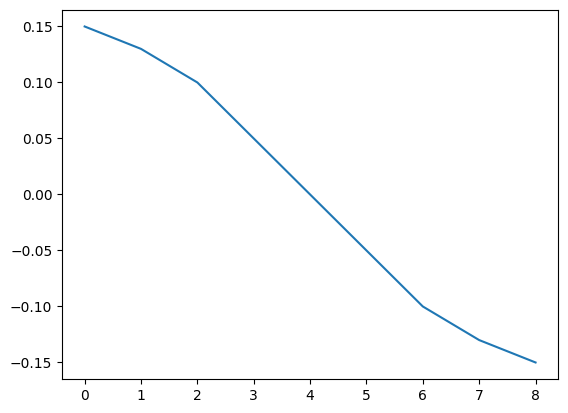

In [88]:
#interface geometry measurement

hx = np.array([0, 0.08, 0.15, 0.21, 0.25, 0.26, 0.25, 0.21,  0.15, 0.08, 0])

# evaluating slope dh/dx
dh_diff = []

#differentian using central difference method
for i in range(1, len(x)-1):
  dh_differentiation = (hx[i+1] - hx[i-1])/(2*h)
  dh_diff.append(dh_differentiation)
plt.plot(dh_diff)
plt.show()

In [89]:
import numpy as np

# Given data
x = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
              3.0, 3.5, 4.0, 4.5, 5.0])

hx = np.array([0, 0.08, 0.15, 0.21, 0.25,
               0.26, 0.25, 0.21, 0.15,
               0.08, 0])

# Step size
h = x[1] - x[0]

# Create empty array for derivative
dh_dx = np.zeros(len(hx))

# Forward difference (first point)
dh_dx[0] = (hx[1] - hx[0]) / h

# Central difference (interior points)
for i in range(1, len(hx)-1):
    dh_dx[i] = (hx[i+1] - hx[i-1]) / (2*h)

# Backward difference (last point)
dh_dx[-1] = (hx[-1] - hx[-2]) / h


# Print results
for i in range(len(x)):
    print(f"x = {x[i]:.1f} , dhx/dx = {dh_dx[i]:.2f}")

x = 0.0 , dhx/dx = 0.16
x = 0.5 , dhx/dx = 0.15
x = 1.0 , dhx/dx = 0.13
x = 1.5 , dhx/dx = 0.10
x = 2.0 , dhx/dx = 0.05
x = 2.5 , dhx/dx = 0.00
x = 3.0 , dhx/dx = -0.05
x = 3.5 , dhx/dx = -0.10
x = 4.0 , dhx/dx = -0.13
x = 4.5 , dhx/dx = -0.15
x = 5.0 , dhx/dx = -0.16
